In [1]:
# Baseline Model
# Goal: Train a simple classifier to predict patient death risk
# No fairness corrections yet - establish performance benchmark

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [2]:
# Load processed data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()
sensitive_test = pd.read_csv("../data/processed/sensitive_test.csv")

print("Data loaded successfully")
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Data loaded successfully
Train size: (239, 12)
Test size: (60, 12)


In [3]:
# Train baseline logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 3))

Model trained successfully

Classification Report:
              precision    recall  f1-score   support

    Survived       0.83      0.93      0.87        41
        Died       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60

ROC-AUC Score: 0.86


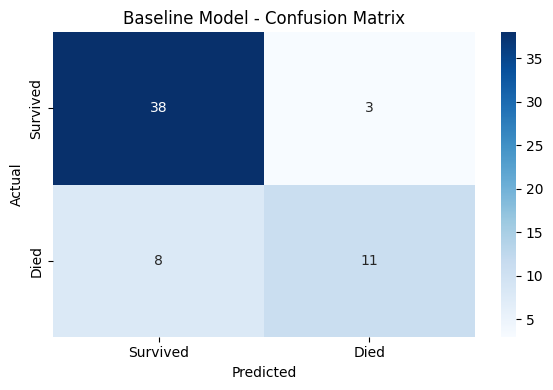

Confusion matrix saved


In [4]:
# Confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/figures/03_confusion_matrix.png')
plt.show()
print("Confusion matrix saved")

In [5]:
# Performance broken down by sex
results = sensitive_test.copy()
results['y_true'] = y_test.values
results['y_pred'] = y_pred
results['y_prob'] = y_prob

print("Performance by Sex:")
for sex, label in [(0, 'Female'), (1, 'Male')]:
    mask = results['sex'] == sex
    subset = results[mask]
    auc = roc_auc_score(subset['y_true'], subset['y_prob'])
    acc = (subset['y_true'] == subset['y_pred']).mean()
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Accuracy: {round(acc, 3)}")
    print(f"  ROC-AUC:  {round(auc, 3)}")

Performance by Sex:

Female (n=19):
  Accuracy: 0.789
  ROC-AUC:  0.81

Male (n=41):
  Accuracy: 0.829
  ROC-AUC:  0.888


In [6]:
# Performance broken down by age group
print("Performance by Age Group:")
for age_group in ['<50', '50-60', '60-70', '70+']:
    mask = results['age_group'] == age_group
    subset = results[mask]
    if len(subset) > 0 and subset['y_true'].sum() > 0:
        auc = roc_auc_score(subset['y_true'], subset['y_prob'])
        acc = (subset['y_true'] == subset['y_pred']).mean()
        print(f"\n{age_group} (n={mask.sum()}):")
        print(f"  Accuracy: {round(acc, 3)}")
        print(f"  ROC-AUC:  {round(auc, 3)}")

Performance by Age Group:

<50 (n=17):
  Accuracy: 0.824
  ROC-AUC:  0.905

50-60 (n=21):
  Accuracy: 0.857
  ROC-AUC:  0.838

60-70 (n=10):
  Accuracy: 0.8
  ROC-AUC:  0.792

70+ (n=12):
  Accuracy: 0.75
  ROC-AUC:  0.781


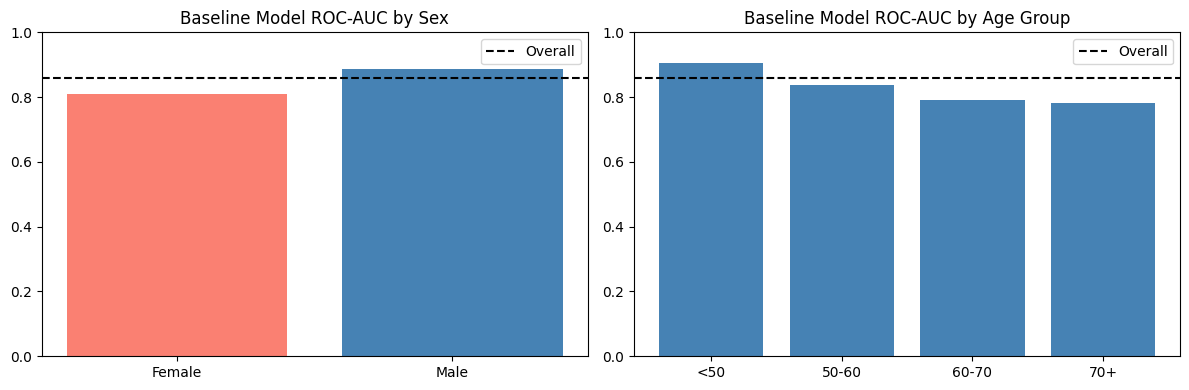

Subgroup performance plot saved


In [7]:
# Visualize performance gap across subgroups
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By sex
sex_data = []
for sex, label in [(0, 'Female'), (1, 'Male')]:
    mask = results['sex'] == sex
    subset = results[mask]
    auc = roc_auc_score(subset['y_true'], subset['y_prob'])
    sex_data.append({'Group': label, 'ROC-AUC': auc})

sex_df = pd.DataFrame(sex_data)
axes[0].bar(sex_df['Group'], sex_df['ROC-AUC'], color=['salmon', 'steelblue'])
axes[0].set_title('Baseline Model ROC-AUC by Sex')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=roc_auc_score(y_test, y_prob), color='black', linestyle='--', label='Overall')
axes[0].legend()

# By age group
age_data = []
for age_group in ['<50', '50-60', '60-70', '70+']:
    mask = results['age_group'] == age_group
    subset = results[mask]
    if len(subset) > 0 and subset['y_true'].sum() > 0:
        auc = roc_auc_score(subset['y_true'], subset['y_prob'])
        age_data.append({'Group': age_group, 'ROC-AUC': auc})

age_df = pd.DataFrame(age_data)
axes[1].bar(age_df['Group'], age_df['ROC-AUC'], color='steelblue')
axes[1].set_title('Baseline Model ROC-AUC by Age Group')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=roc_auc_score(y_test, y_prob), color='black', linestyle='--', label='Overall')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/04_subgroup_performance.png')
plt.show()
print("Subgroup performance plot saved")